Лаб.работа №6.

In [92]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import matplotlib.patches as mpatches
import time
import collections
from collections import Counter
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from scipy.stats import norm
from sklearn.decomposition import PCA, TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score, normalized_mutual_info_score
warnings.filterwarnings('ignore')

Подготовка датасета.

In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
dataset = pd.read_csv('/content/drive/MyDrive/DARWIN.csv')
print("Информация о датасете:")
dataset.head()

Информация о датасете:


,ID,air_time1,disp_index1,gmrt_in_air1,gmrt_on_paper1,max_x_extension1,max_y_extension1,mean_acc_in_air1,mean_acc_on_paper1,mean_gmrt1,...,mean_jerk_in_air25,mean_jerk_on_paper25,mean_speed_in_air25,mean_speed_on_paper25,num_of_pendown25,paper_time25,pressure_mean25,pressure_var25,total_time25,class
0,id_1,5160,0.000013,120.804174,86.853334,957,6601,0.361800,0.217459,103.828754,...,0.141434,0.024471,5.596487,3.184589,71,40120,1749.278166,296102.7676,144605,P
1,id_2,51980,0.000016,115.318238,83.448681,1694,6998,0.272513,0.144880,99.383459,...,0.049663,0.018368,1.665973,0.950249,129,126700,1504.768272,278744.2850,298640,P
2,id_3,2600,0.000010,229.933997,172.761858,2333,5802,0.387020,0.181342,201.347928,...,0.178194,0.017174,4.000781,2.392521,74,45480,1431.443492,144411.7055,79025,P
3,id_4,2130,0.000010,369.403342,183.193104,1756,8159,0.556879,0.164502,276.298223,...,0.113905,0.019860,4.206746,1.613522,123,67945,1465.843329,230184.7154,181220,P
4,id_5,2310,0.000007,257.997131,111.275889,987,4732,0.266077,0.145104,184.636510,...,0.121782,0.020872,3.319036,1.680629,92,37285,1841.702561,158290.0255,72575,P


In [36]:
dataset.describe()

,air_time1,disp_index1,gmrt_in_air1,gmrt_on_paper1,max_x_extension1,max_y_extension1,mean_acc_in_air1,mean_acc_on_paper1,mean_gmrt1,mean_jerk_in_air1,...,mean_gmrt25,mean_jerk_in_air25,mean_jerk_on_paper25,mean_speed_in_air25,mean_speed_on_paper25,num_of_pendown25,paper_time25,pressure_mean25,pressure_var25,total_time25
count,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,...,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,174.000000,1.740000e+02
mean,5664.166667,0.000010,297.666685,200.504413,1977.965517,7323.896552,0.416374,0.179823,249.085549,0.067556,...,221.360646,0.148286,0.019934,4.472643,2.871613,85.839080,43109.712644,1629.585962,163061.767360,1.642033e+05
std,12653.772746,0.000003,183.943181,111.629546,1648.306365,2188.290512,0.381837,0.064693,132.698462,0.074776,...,63.762013,0.062207,0.002388,1.501411,0.852809,27.485518,19092.024337,324.142316,56845.610814,4.969397e+05
min,65.000000,0.000002,28.734515,29.935835,754.000000,561.000000,0.067748,0.096631,41.199445,0.011861,...,69.928033,0.030169,0.014987,1.323565,0.950249,32.000000,15930.000000,474.049462,26984.926660,2.998000e+04
25%,1697.500000,0.000008,174.153023,136.524742,1362.500000,6124.000000,0.218209,0.146647,161.136182,0.029523,...,178.798382,0.107732,0.018301,3.485934,2.401199,66.000000,32803.750000,1499.112088,120099.046800,5.917500e+04
50%,2890.000000,0.000009,255.791452,176.494494,1681.000000,6975.500000,0.275184,0.163659,224.445268,0.039233,...,217.431621,0.140483,0.019488,4.510578,2.830672,81.000000,37312.500000,1729.385010,158236.771800,7.611500e+04
75%,4931.250000,0.000011,358.917885,234.052560,2082.750000,8298.500000,0.442706,0.188879,294.392298,0.071057,...,264.310776,0.199168,0.021134,5.212794,3.335828,101.500000,46533.750000,1865.626974,200921.078475,1.275425e+05
max,109965.000000,0.000028,1168.328276,865.210522,18602.000000,15783.000000,2.772566,0.627350,836.784702,0.543199,...,437.373267,0.375078,0.029227,10.416715,5.602909,209.000000,139575.000000,1999.775983,352981.850000,5.704200e+06


In [37]:
dataset.isnull().sum()

,0
ID,0
air_time1,0
disp_index1,0
gmrt_in_air1,0
gmrt_on_paper1,0
...,...
paper_time25,0
pressure_mean25,0
pressure_var25,0
total_time25,0


In [38]:
dataset.columns

Index(['ID', 'air_time1', 'disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1',
       'max_x_extension1', 'max_y_extension1', 'mean_acc_in_air1',
       'mean_acc_on_paper1', 'mean_gmrt1',
       ...
       'mean_jerk_in_air25', 'mean_jerk_on_paper25', 'mean_speed_in_air25',
       'mean_speed_on_paper25', 'num_of_pendown25', 'paper_time25',
       'pressure_mean25', 'pressure_var25', 'total_time25', 'class'],
      dtype='object', length=452)

In [39]:
print('Обычные транзакции составляют', round(dataset['class'].value_counts()[0]/len(dataset) * 100,2), '% данных')
print('Мошеннические транзакции составляют', round(dataset['class'].value_counts()[1]/len(dataset) * 100,2), '% данных')

Обычные транзакции составляют 51.15 % данных
Мошеннические транзакции составляют 48.85 % данных


In [40]:
print(dataset['class'].value_counts())
print(dataset['class'].value_counts()[0])
print(dataset['class'].value_counts()[1])

class
P    89
H    85
Name: count, dtype: int64
89
85


In [41]:
n_trans = round(dataset['class'].value_counts()[0]/len(dataset) * 100,2)
f_trans = round(dataset['class'].value_counts()[1]/len(dataset) * 100,2)
print(f'Обычные транзакции составляют  {n_trans} % данных')
print(f'Мошеннические транзакции составляют  {f_trans} % данных')

Обычные транзакции составляют  51.15 % данных
Мошеннические транзакции составляют  48.85 % данных


Графики распределения.

Text(0.5, 1.0, 'Распределение классов \n (0: Не мошенник || 1: Мошенник)')

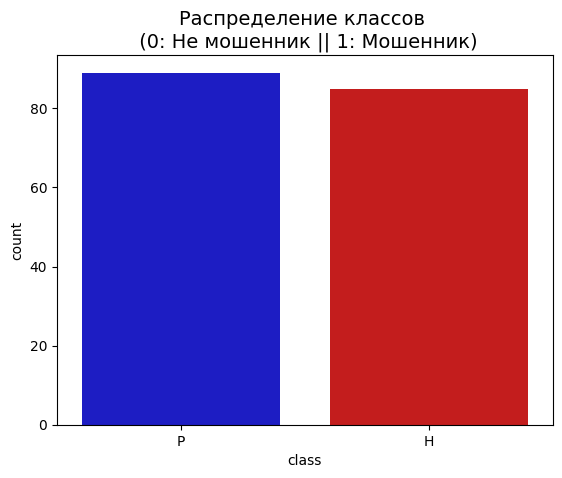

In [42]:
colors = ["#0101DF", "#DF0101"]
sns.countplot(x='class', data=dataset, palette=colors)
plt.title('Распределение классов \n (0: Не мошенник || 1: Мошенник)', fontsize=14)

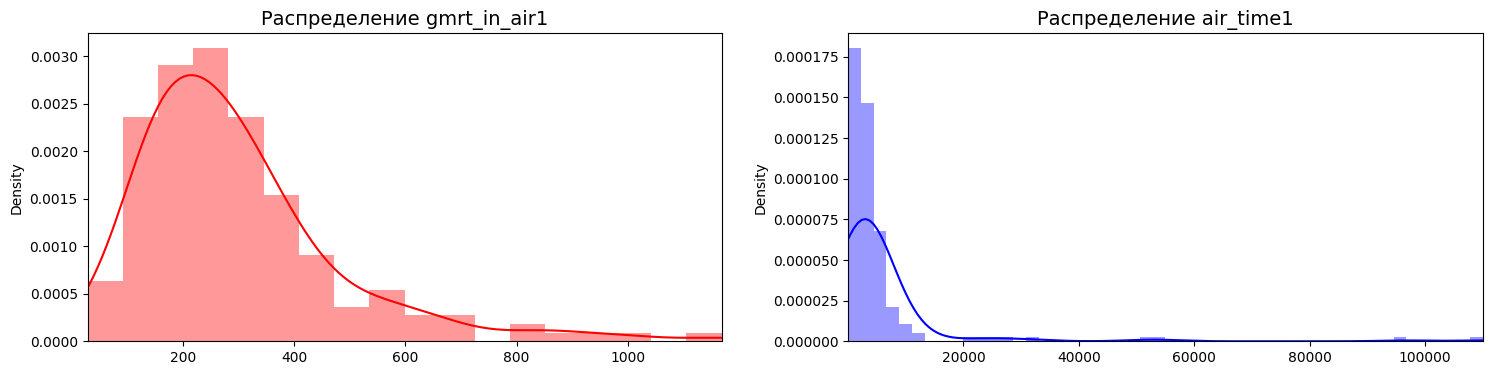

In [43]:
fig, ax = plt.subplots(1, 2, figsize=(18,4))
amount_val = dataset['gmrt_in_air1'].values
time_val = dataset['air_time1'].values
sns.distplot(amount_val, ax=ax[0], color='r')
ax[0].set_title('Распределение gmrt_in_air1', fontsize=14)
ax[0].set_xlim([min(amount_val), max(amount_val)])
sns.distplot(time_val, ax=ax[1], color='b')
ax[1].set_title('Распределение air_time1', fontsize=14)
ax[1].set_xlim([min(time_val), max(time_val)])
plt.show()

Разделение данных.

In [44]:
rob_scaler = RobustScaler()
X = dataset.drop('class', axis=1)
y = dataset['class']
original_Xtrain, original_Xtest, original_ytrain, original_ytest = train_test_split(X, y, test_size=0.2,
                                                                                    random_state = 42)
rt_tmp = original_Xtrain['air_time1']
print (f'Тип данных original_Xtrain["air_time1"] {type(rt_tmp)}')
print (f'Тип данных original_Xtrain["air_time1"].values {type(rt_tmp.values)}')
print (f'Данные original_Xtrain["air_time1"].values {rt_tmp.values}')
print (f'Тип данных original_Xtrain["air_time1"].values.reshape(-1,1) {type(rt_tmp.values.reshape(-1,1))}')
print (f'Данные original_Xtrain["air_time1"].values.reshape(-1,1) \n{rt_tmp.values.reshape(-1,1)} \n')
original_Xtrain['scaled_air_time1'] = rob_scaler.fit_transform(original_Xtrain['air_time1'].values.reshape(-1,1))
original_Xtest['scaled_air_time1'] = rob_scaler.fit_transform(original_Xtest['air_time1'].values.reshape(-1,1))
original_Xtrain['scaled_gmrt_in_air1'] = rob_scaler.fit_transform(original_Xtrain['gmrt_in_air1'].values.reshape(-1,1))
original_Xtest['scaled_gmrt_in_air1'] = rob_scaler.fit_transform(original_Xtest['gmrt_in_air1'].values.reshape(-1,1))
original_Xtrain.drop(['gmrt_in_air1','air_time1'], axis=1, inplace=True)
original_Xtest.drop(['gmrt_in_air1','air_time1'], axis=1, inplace=True)
original_Xtrain = original_Xtrain.values
original_Xtest = original_Xtest.values
original_ytrain = original_ytrain.values
original_ytest = original_ytest.values
train_unique_label, train_counts_label = np.unique(original_ytrain, return_counts=True)
test_unique_label, test_counts_label = np.unique(original_ytest, return_counts=True)
print('Распределение классов: \n')
print("Обучающий набор:", train_counts_label/ len(original_ytrain))
print("Тестовый набор:", test_counts_label/ len(original_ytest))

Тип данных original_Xtrain["air_time1"] <class 'pandas.core.series.Series'>
Тип данных original_Xtrain["air_time1"].values <class 'numpy.ndarray'>
Данные original_Xtrain["air_time1"].values [   540   1800   2740   2635   2975    400   4100   1765   2600   3590
  22520   8385    685   1755   3365     65   1615   2785   5400  12960
  26050   4200   1860    690   4485   2039   1970   7285   2930   6415
   1385   1000   2310   4410    820   3030   2960   2985   2140    900
   5160  53875   5120   1835   3720   2175   4115   5705   1285   2915
   4695   1940   3235   2970   3490    690   7770   1920   2130   2930
   2055   4450   5020   1730   3900   7820   4515   2630    950   3275
   9375   4015   1760    845    345   3990   4185   1920   3315   2130
    805    670    720   3490   8905    900   1580   1510   3055   2880
   2275   1270    980   2580   1215    835   4860   1190   4830   6475
   1730  12980   1560   1705   1695   2035   2725   3845  21800   1375
 109965   3830   5770   2400 

Матрица корреляций.

Уникальные значения в class: ['P' 'H']
После преобразования: [1 0]


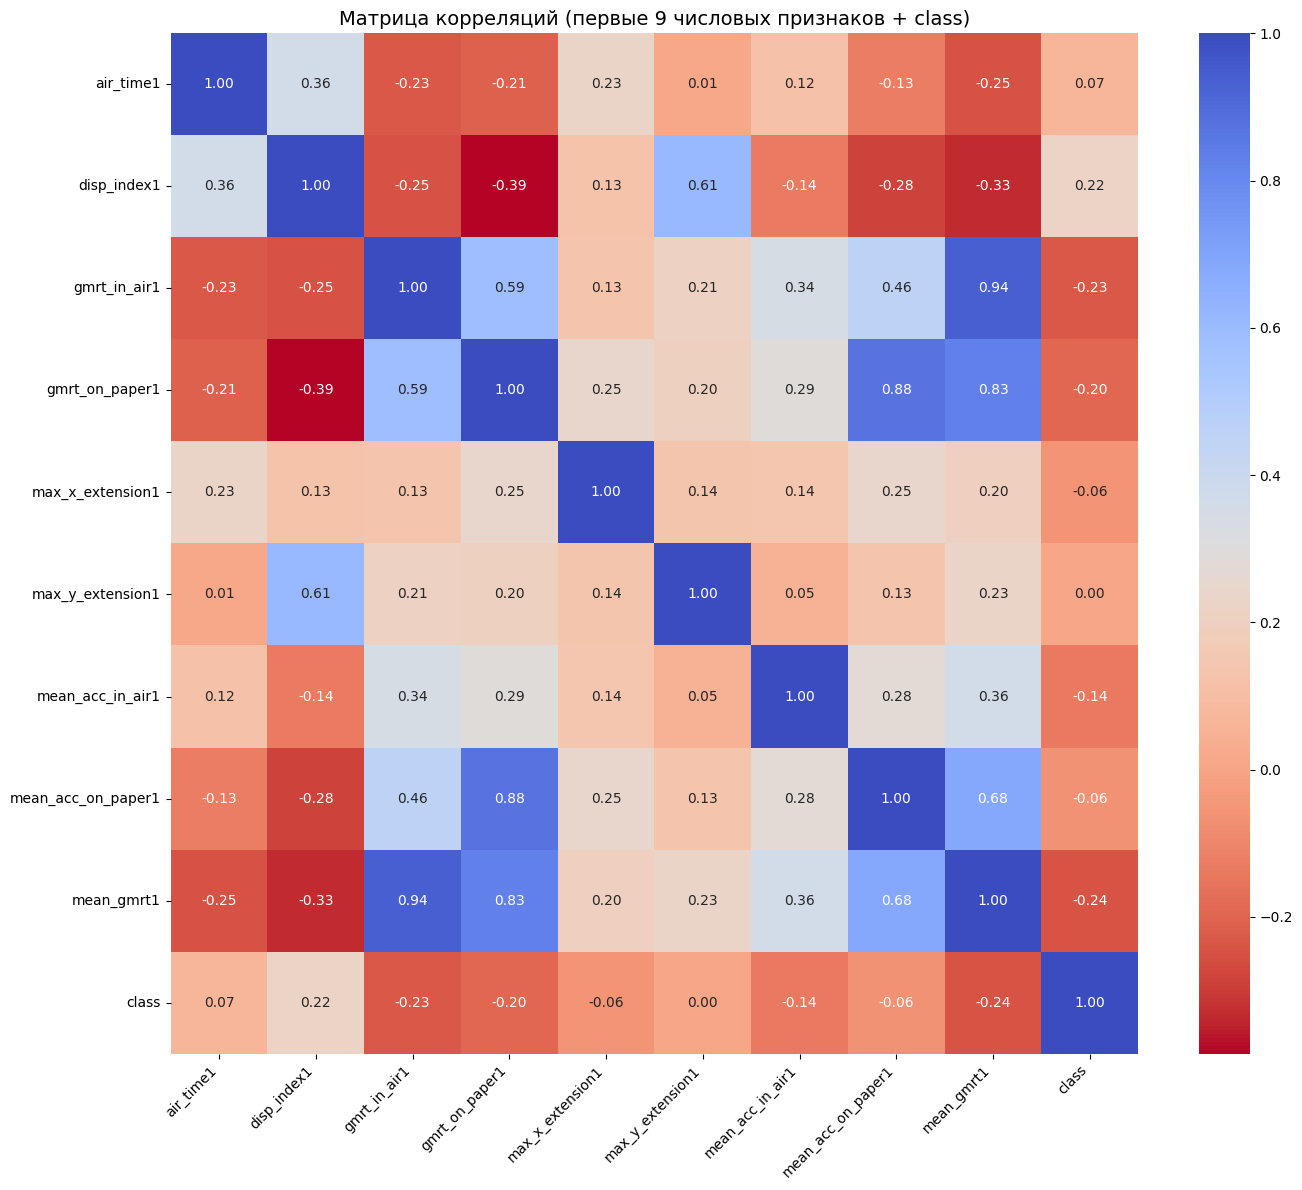


Корреляция с class:
disp_index1           0.222050
air_time1             0.068355
max_y_extension1      0.004928
max_x_extension1     -0.058278
mean_acc_on_paper1   -0.063417
mean_acc_in_air1     -0.139833
gmrt_on_paper1       -0.196220
gmrt_in_air1         -0.229922
mean_gmrt1           -0.241889
Name: class, dtype: float64


In [58]:
# Создайте копию датасета
dataset_numeric = dataset.copy()

# Посмотрите уникальные значения
print("Уникальные значения в class:", dataset_numeric['class'].unique())

# Если, например, 'P' означает мошенничество, а 'N' - нет
# Замените на свои значения
dataset_numeric['class'] = dataset_numeric['class'].replace({'P': 1, 'H': 0})  # или наоборот

# Проверьте результат
print("После преобразования:", dataset_numeric['class'].unique())

# Выберите только числовые столбцы
numeric_columns = dataset_numeric.select_dtypes(include=['float64', 'int64']).columns

# Возьмите первые 9 числовых столбцов (без class) и добавьте class
numeric_cols_without_class = [col for col in numeric_columns if col != 'class']
first_9_numeric = numeric_cols_without_class[:9]
selected_columns = first_9_numeric + ['class']

# Вычислите корреляцию
sub_sample_corr = dataset_numeric[selected_columns].corr()

# Постройте тепловую карту
f, ax = plt.subplots(1, 1, figsize=(14, 12))
sns.heatmap(sub_sample_corr, cmap='coolwarm_r', annot=True, fmt='.2f', annot_kws={'size':10}, ax=ax)
ax.set_title('Матрица корреляций (первые 9 числовых признаков + class)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nКорреляция с class:")
print(sub_sample_corr['class'].drop('class').sort_values(ascending=False))

Boxplot.

Отрицательные корреляции:

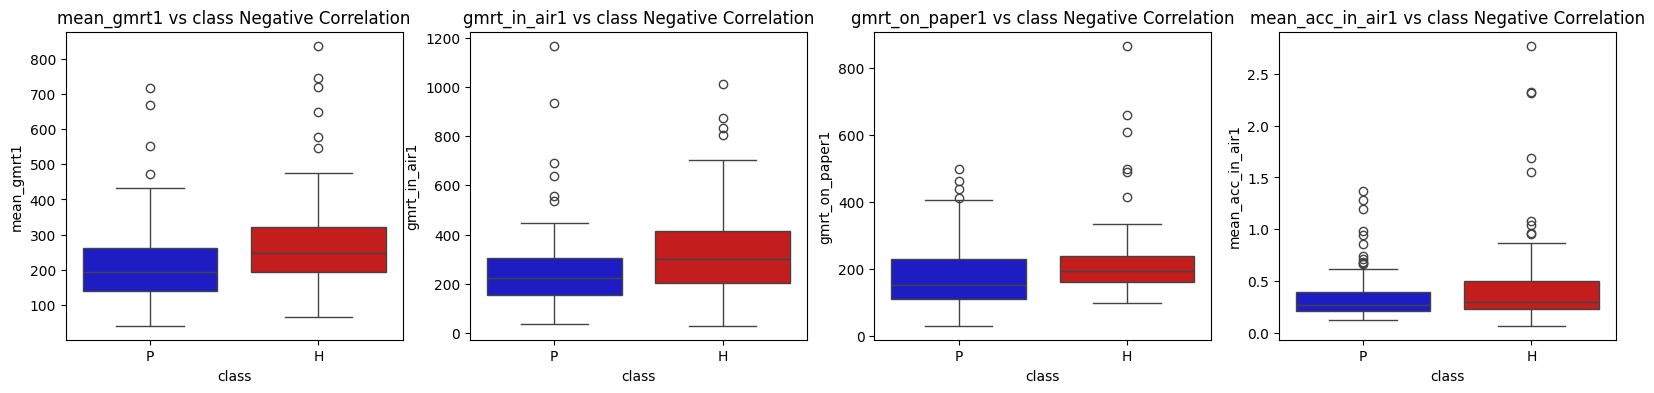

In [59]:
f, axes = plt.subplots(ncols=4, figsize=(20,4))
sns.boxplot(x='class', y='mean_gmrt1', data=dataset, palette=colors, ax=axes[0])
axes[0].set_title('mean_gmrt1 vs class Negative Correlation')
sns.boxplot(x='class', y='gmrt_in_air1', data=dataset, palette=colors, ax=axes[1])
axes[1].set_title('gmrt_in_air1 vs class Negative Correlation')
sns.boxplot(x='class', y='gmrt_on_paper1', data=dataset, palette=colors, ax=axes[2])
axes[2].set_title('gmrt_on_paper1 vs class Negative Correlation')
sns.boxplot(x='class', y='mean_acc_in_air1', data=dataset, palette=colors, ax=axes[3])
axes[3].set_title('mean_acc_in_air1 vs class Negative Correlation')
plt.show()

Положительные корреляции:

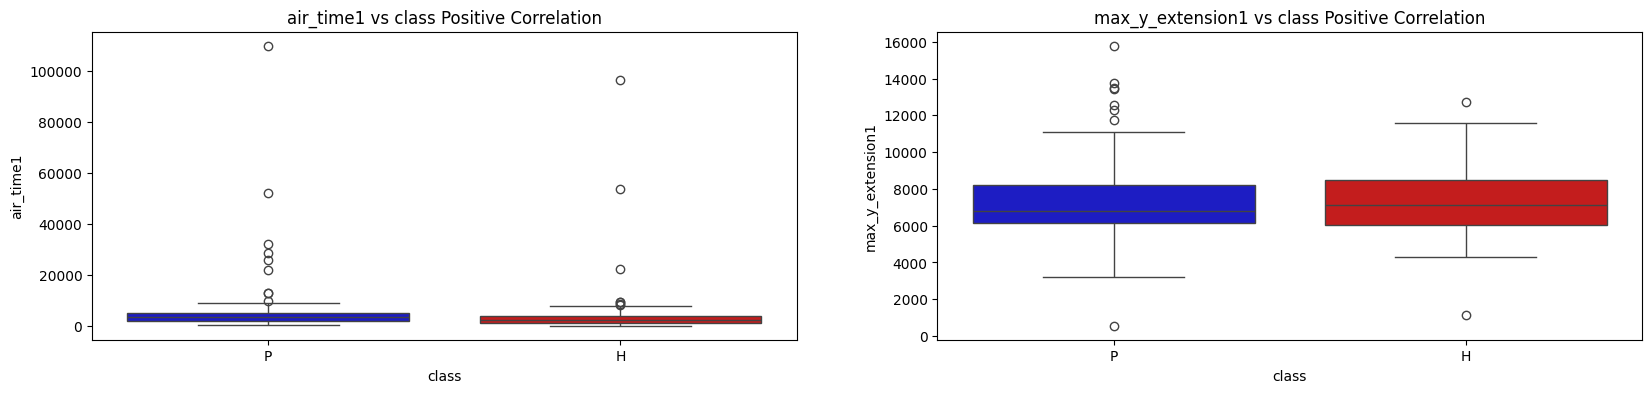

In [64]:
f, axes = plt.subplots(ncols=2, figsize=(20,4))
sns.boxplot(x='class', y='air_time1', data=dataset, palette=colors, ax=axes[0])
axes[0].set_title('air_time1 vs class Positive Correlation')
sns.boxplot(x='class', y='max_y_extension1', data=dataset, palette=colors, ax=axes[1])
axes[1].set_title('max_y_extension1 vs class Positive Correlation')
plt.show()

Обработка выбросов.

Уникальные значения в class: ['P' 'H']
Мошенничество: P
Не мошенничество: H


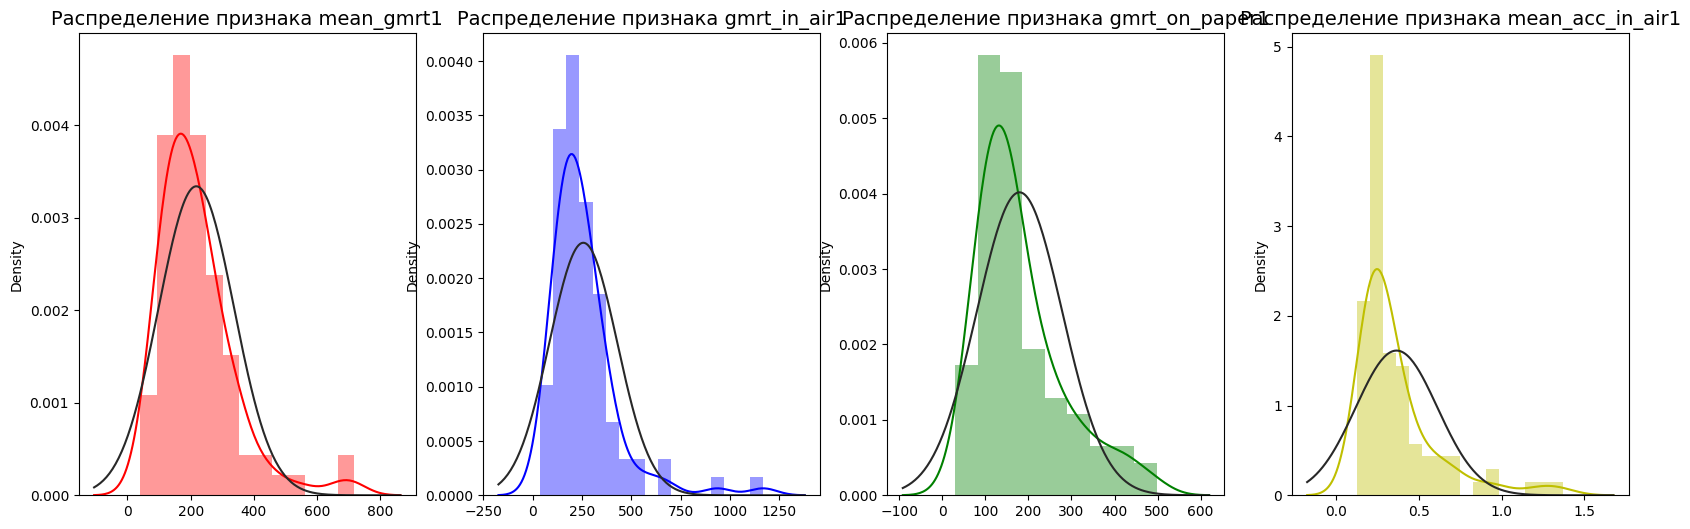

In [83]:
unique_classes = dataset['class'].unique()
print("Уникальные значения в class:", unique_classes)
if len(unique_classes) == 2:
    fraud_value = unique_classes[0]
    non_fraud_value = unique_classes[1]
    print(f"Мошенничество: {fraud_value}")
    print(f"Не мошенничество: {non_fraud_value}")
    f, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(20, 6))
    mean_gmrt1_fraud_dist = dataset['mean_gmrt1'].loc[dataset['class'] == fraud_value].values
    if len(mean_gmrt1_fraud_dist) > 1:
        sns.distplot(mean_gmrt1_fraud_dist, ax=ax1, fit=norm, color='r')
    ax1.set_title('Распределение признака mean_gmrt1', fontsize=14)

    gmrt_in_air1_fraud_dist = dataset['gmrt_in_air1'].loc[dataset['class'] == fraud_value].values
    if len(gmrt_in_air1_fraud_dist) > 1:
        sns.distplot(gmrt_in_air1_fraud_dist, ax=ax2, fit=norm, color='b')
    ax2.set_title('Распределение признака gmrt_in_air1', fontsize=14)

    gmrt_on_paper1_fraud_dist = dataset['gmrt_on_paper1'].loc[dataset['class'] == fraud_value].values
    if len(gmrt_on_paper1_fraud_dist) > 1:
        sns.distplot(gmrt_on_paper1_fraud_dist, ax=ax3, fit=norm, color='g')
    ax3.set_title('Распределение признака gmrt_on_paper1', fontsize=14)

    mean_acc_in_air1_fraud_dist = dataset['mean_acc_in_air1'].loc[dataset['class'] == fraud_value].values
    if len(mean_acc_in_air1_fraud_dist) > 1:
        sns.distplot(mean_acc_in_air1_fraud_dist, ax=ax4, fit=norm, color='y')
    ax4.set_title('Распределение признака mean_acc_in_air1', fontsize=14)

Названия столбцов в датасете:
['ID', 'air_time1', 'disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1', 'max_x_extension1', 'max_y_extension1', 'mean_acc_in_air1', 'mean_acc_on_paper1', 'mean_gmrt1', 'mean_jerk_in_air1', 'mean_jerk_on_paper1', 'mean_speed_in_air1', 'mean_speed_on_paper1', 'num_of_pendown1', 'paper_time1', 'pressure_mean1', 'pressure_var1', 'total_time1', 'air_time2', 'disp_index2', 'gmrt_in_air2', 'gmrt_on_paper2', 'max_x_extension2', 'max_y_extension2', 'mean_acc_in_air2', 'mean_acc_on_paper2', 'mean_gmrt2', 'mean_jerk_in_air2', 'mean_jerk_on_paper2', 'mean_speed_in_air2', 'mean_speed_on_paper2', 'num_of_pendown2', 'paper_time2', 'pressure_mean2', 'pressure_var2', 'total_time2', 'air_time3', 'disp_index3', 'gmrt_in_air3', 'gmrt_on_paper3', 'max_x_extension3', 'max_y_extension3', 'mean_acc_in_air3', 'mean_acc_on_paper3', 'mean_gmrt3', 'mean_jerk_in_air3', 'mean_jerk_on_paper3', 'mean_speed_in_air3', 'mean_speed_on_paper3', 'num_of_pendown3', 'paper_time3', 'pressure_mean3',

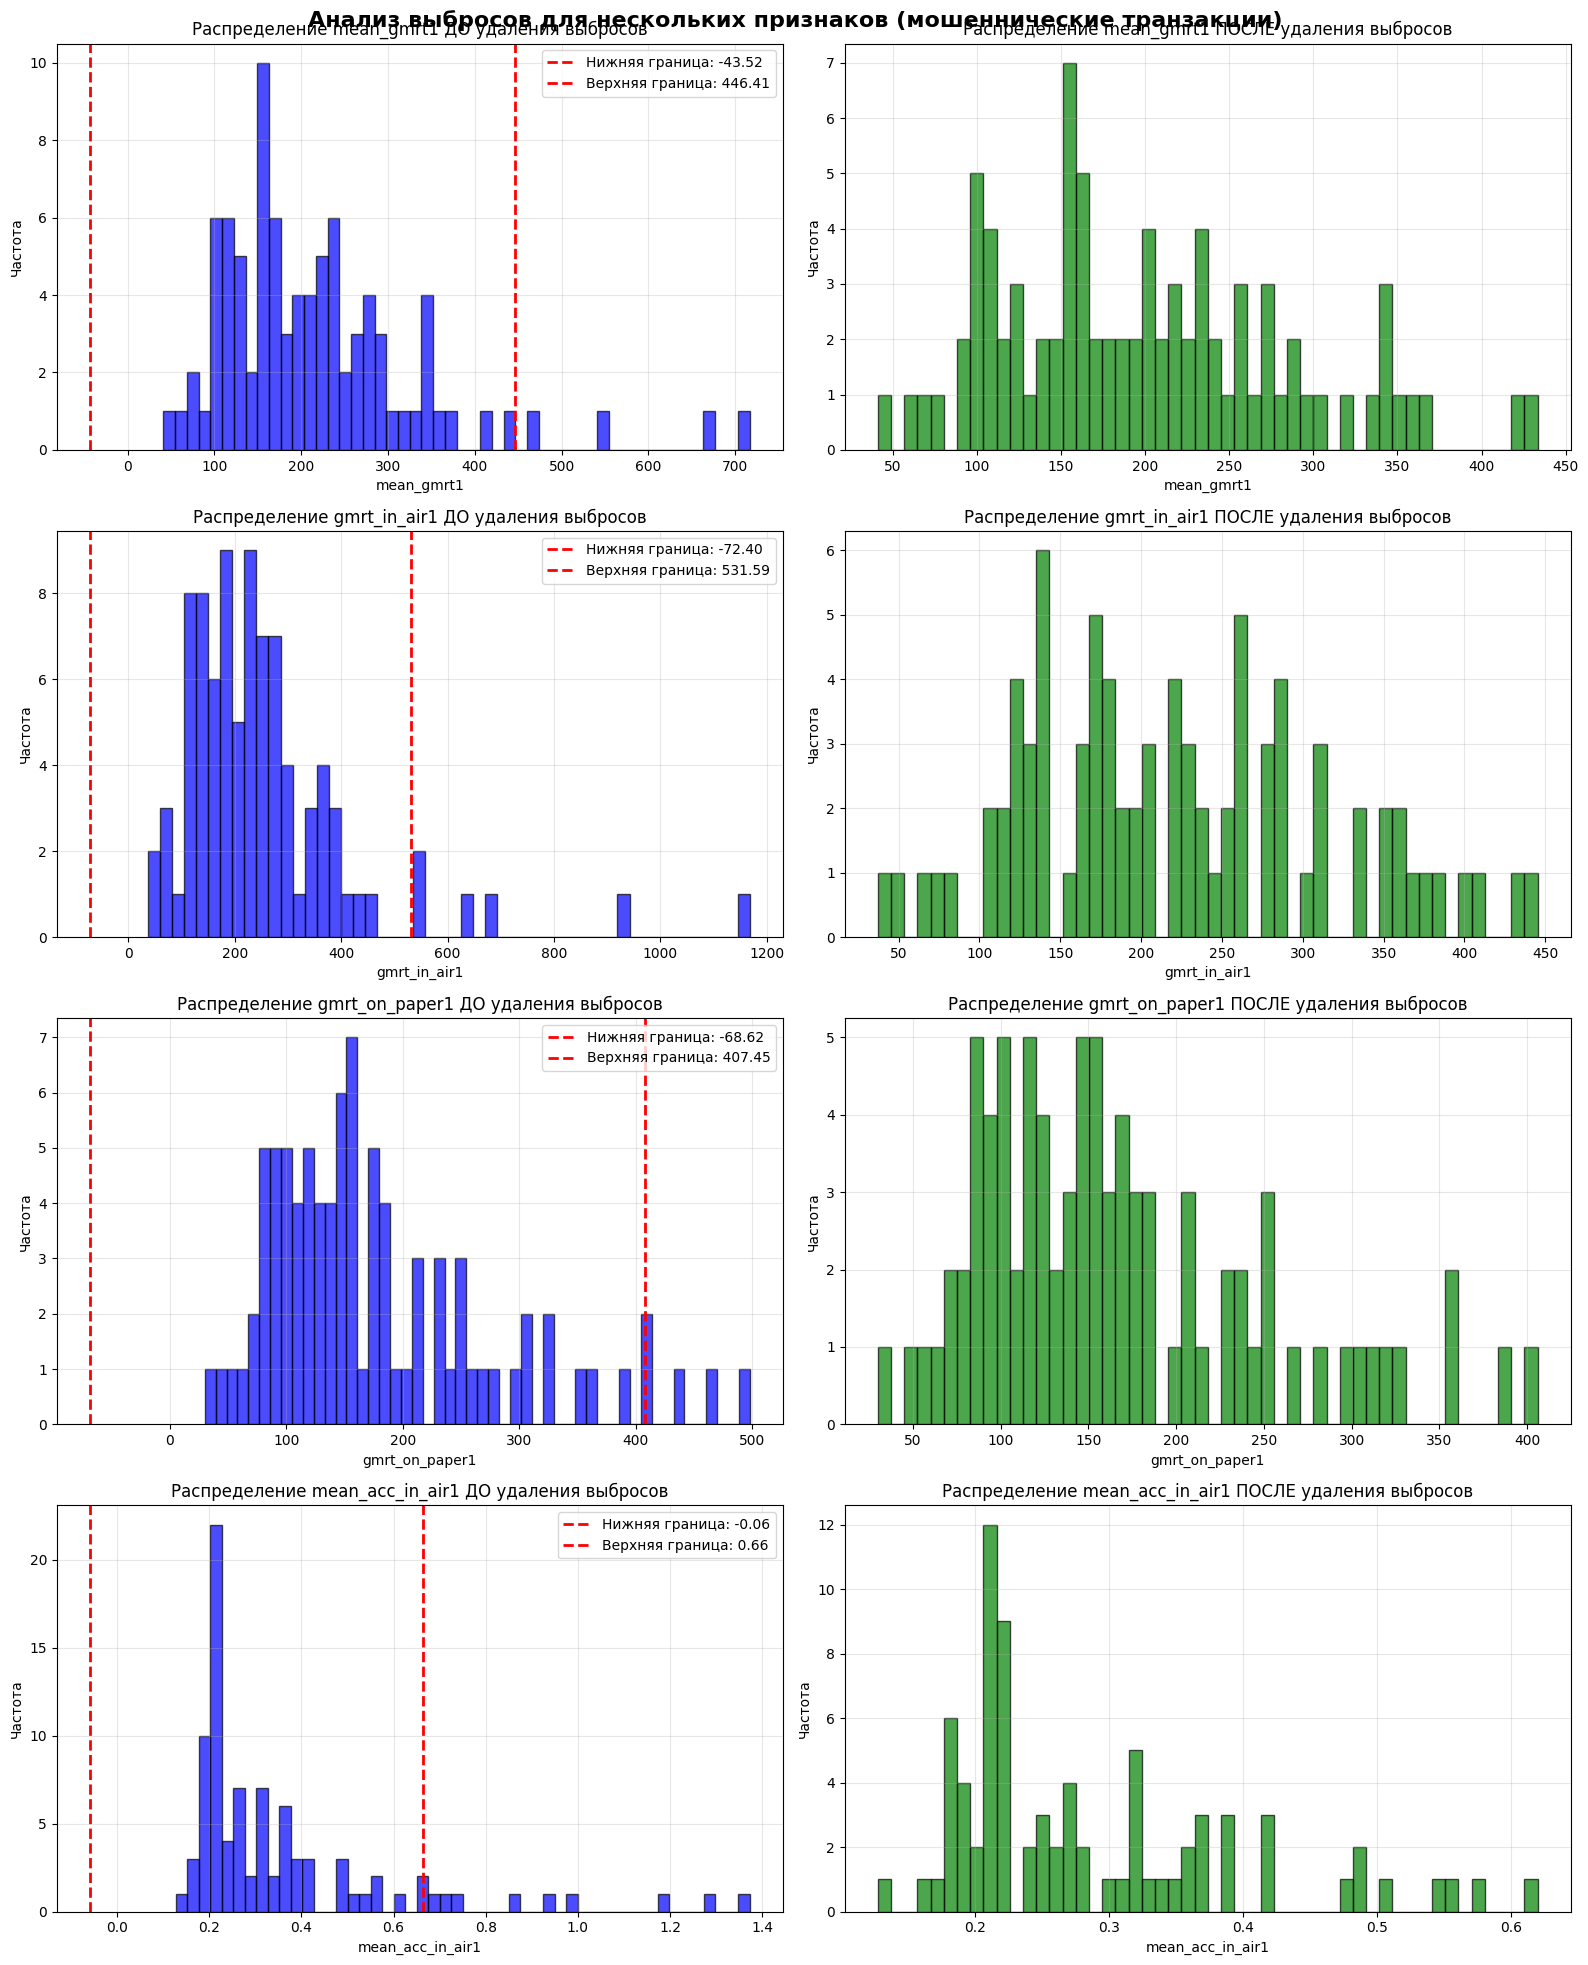

In [85]:
print("Названия столбцов в датасете:")
print(dataset.columns.tolist())
if dataset['class'].dtype == 'object':
    new_df = dataset.copy()
    new_df['class'] = new_df['class'].map({'P': 1, 'H': 0})
features = ['mean_gmrt1', 'gmrt_in_air1', 'gmrt_on_paper1', 'mean_acc_in_air1']
fraud_data = {}
cleaned_data = {}
for feature in features:
    fraud_data[feature] = new_df[feature].loc[new_df['class'] == 1].values
    if len(fraud_data[feature]) > 0:
        q25, q75 = np.percentile(fraud_data[feature], 25), np.percentile(fraud_data[feature], 75)
        feature_iqr = q75 - q25
        feature_cut_off = feature_iqr * 1.5
        feature_lower, feature_upper = q25 - feature_cut_off, q75 + feature_cut_off
        outliers = [x for x in fraud_data[feature] if x < feature_lower or x > feature_upper]
        new_df_without_outliers = new_df.drop(new_df[(new_df[feature] > feature_upper) | (new_df[feature] < feature_lower)].index)
        cleaned_data[feature] = new_df_without_outliers[feature].loc[new_df_without_outliers['class'] == 1].values
    else:
        cleaned_data[feature] = []
print("Построение графиков для всех признаков")
fig, axes = plt.subplots(len(features), 2, figsize=(16, 5*len(features)))
if len(features) == 1:
    axes = axes.reshape(1, -1)

for idx, feature in enumerate(features):
    if len(fraud_data[feature]) > 0 and len(cleaned_data[feature]) > 0:
        axes[idx, 0].hist(fraud_data[feature], bins=50, color='blue', alpha=0.7, edgecolor='black')
        q25, q75 = np.percentile(fraud_data[feature], 25), np.percentile(fraud_data[feature], 75)
        feature_iqr = q75 - q25
        feature_cut_off = feature_iqr * 1.5
        feature_lower, feature_upper = q25 - feature_cut_off, q75 + feature_cut_off
        axes[idx, 0].axvline(feature_lower, color='red', linestyle='--', linewidth=2,
                            label=f'Нижняя граница: {feature_lower:.2f}')
        axes[idx, 0].axvline(feature_upper, color='red', linestyle='--', linewidth=2,
                            label=f'Верхняя граница: {feature_upper:.2f}')
        axes[idx, 0].set_title(f'Распределение {feature} ДО удаления выбросов', fontsize=12)
        axes[idx, 0].set_xlabel(feature, fontsize=10)
        axes[idx, 0].set_ylabel('Частота', fontsize=10)
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, alpha=0.3)
        axes[idx, 1].hist(cleaned_data[feature], bins=50, color='green', alpha=0.7, edgecolor='black')
        axes[idx, 1].set_title(f'Распределение {feature} ПОСЛЕ удаления выбросов', fontsize=12)
        axes[idx, 1].set_xlabel(feature, fontsize=10)
        axes[idx, 1].set_ylabel('Частота', fontsize=10)
        axes[idx, 1].grid(True, alpha=0.3)
    else:
        axes[idx, 0].text(0.5, 0.5, f'Нет данных для {feature}',
                         ha='center', va='center', transform=axes[idx, 0].transAxes)
        axes[idx, 0].set_title(f'Распределение {feature} (нет данных)', fontsize=12)
        axes[idx, 1].text(0.5, 0.5, f'Нет данных для {feature}',
                         ha='center', va='center', transform=axes[idx, 1].transAxes)
        axes[idx, 1].set_title(f'Распределение {feature} (нет данных)', fontsize=12)

plt.suptitle('Анализ выбросов для нескольких признаков (мошеннические транзакции)',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Подготовка данных...
Всего столбцов в датасете: 452
Числовых столбцов: 451
Размерность исходных данных: (174, 450)
Количество признаков: 450
Первые 5 признаков: ['air_time1', 'disp_index1', 'gmrt_in_air1', 'gmrt_on_paper1', 'max_x_extension1']

Проверка данных:
NaN значений: 0
Бесконечных значений: 0

Данные после стандартизации:
Среднее: -0.000000
Стандартное отклонение: 1.000000
1. PCA (Principal Component Analysis)
Размерность после PCA: (174, 50)
Объясненная дисперсия для 50 компонент: 77.89%
Количество компонент для 95% дисперсии: 1


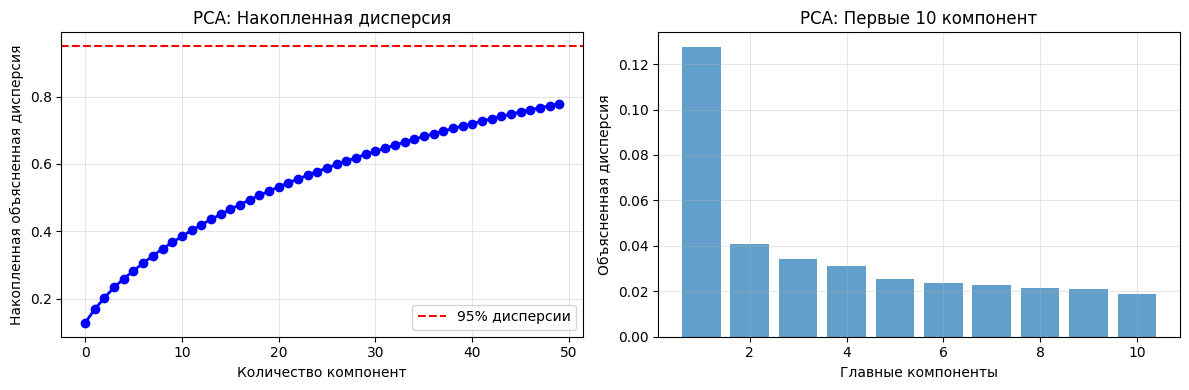

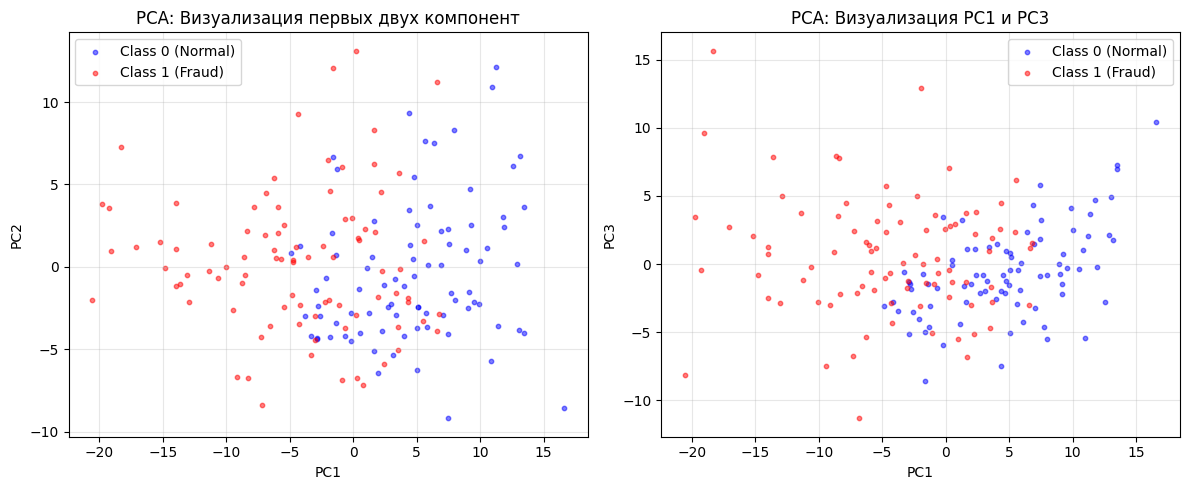

2. t-SNE (t-Distributed Stochastic Neighbor Embedding)
Используется 174 образцов для t-SNE
Размерность после t-SNE: (174, 2)


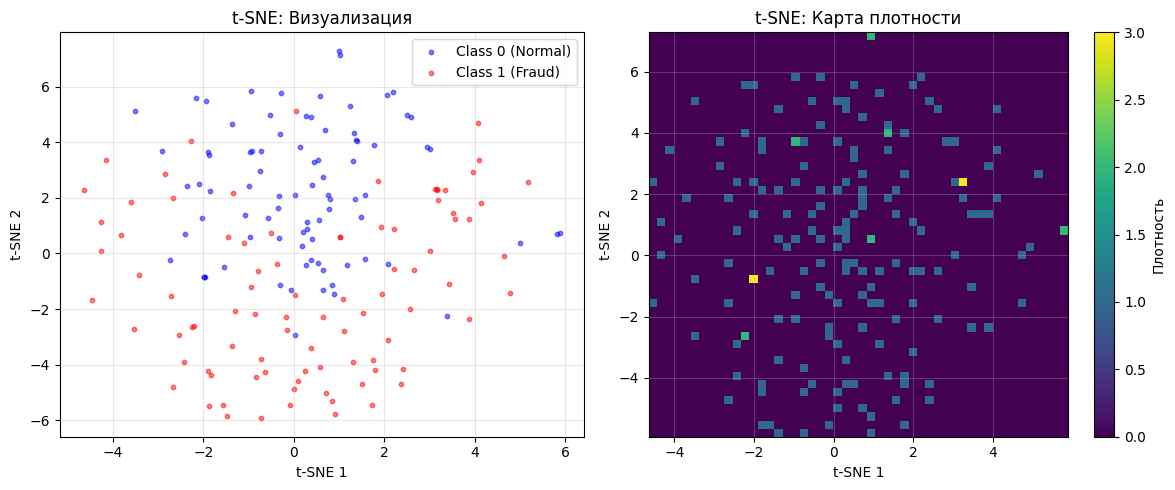

3. Truncated SVD (Singular Value Decomposition)
Размерность после Truncated SVD: (174, 50)
Объясненная дисперсия для 50 компонент: 77.88%


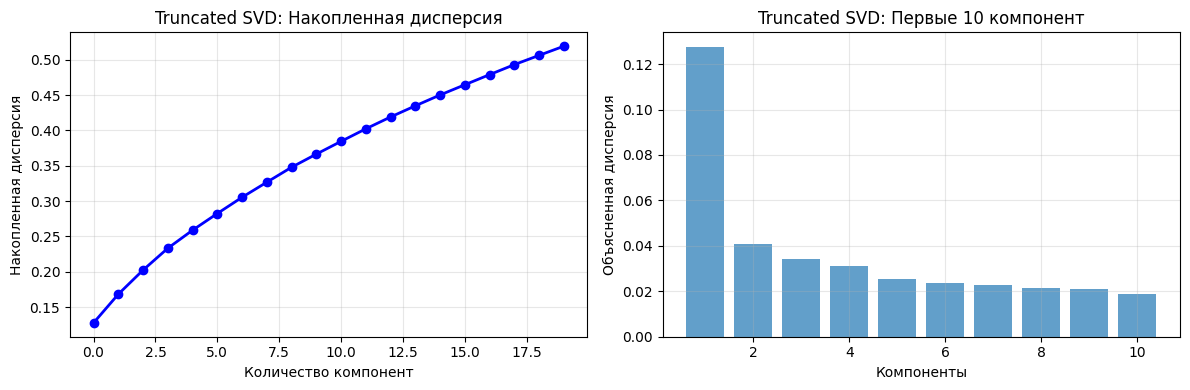

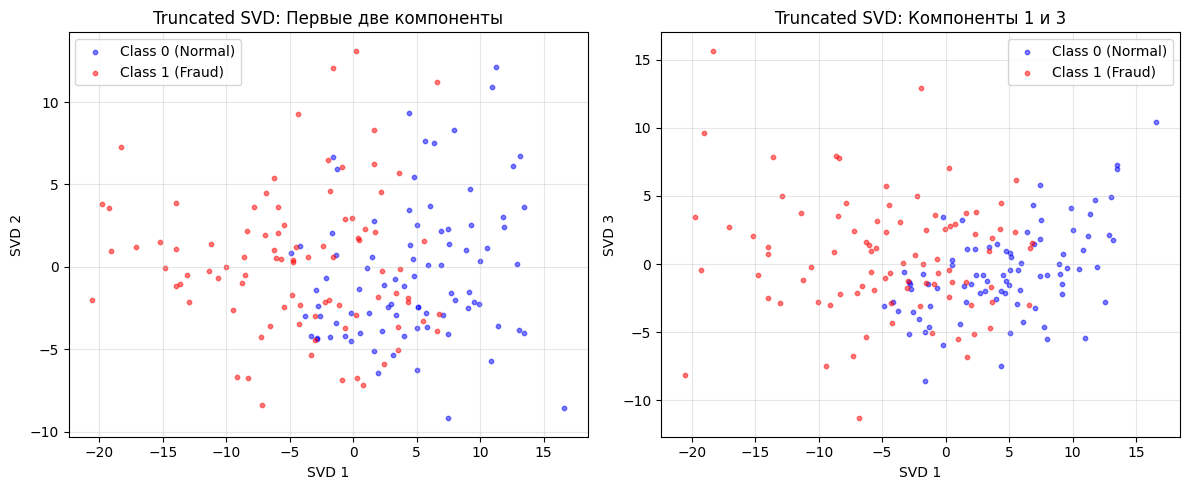

4. Кластеризация на пониженных размерностях

KMeans на PCA:
  Silhouette Score: 0.1979
  Adjusted Rand Index: 0.2069
  Normalized Mutual Information: 0.1674


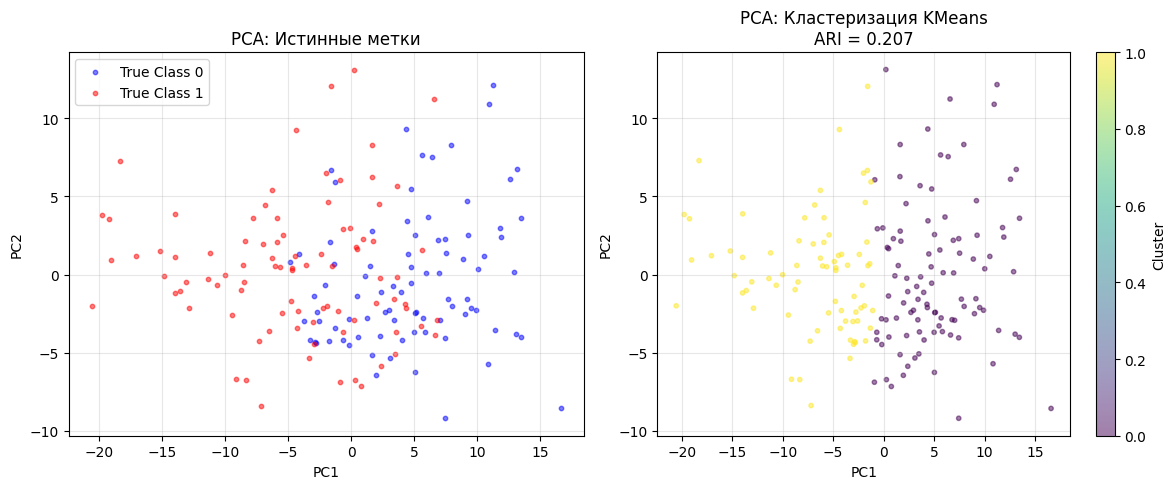


KMeans на t-SNE:
  Silhouette Score: 0.4046
  Adjusted Rand Index: 0.1571
  Normalized Mutual Information: 0.1261


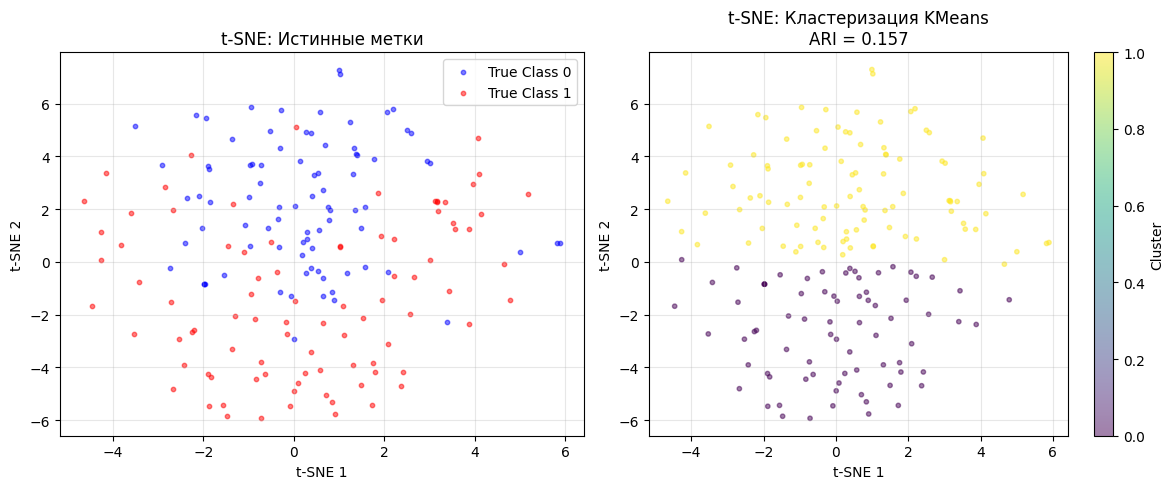


KMeans на Truncated SVD:
  Silhouette Score: 0.1979
  Adjusted Rand Index: 0.2069
  Normalized Mutual Information: 0.1674


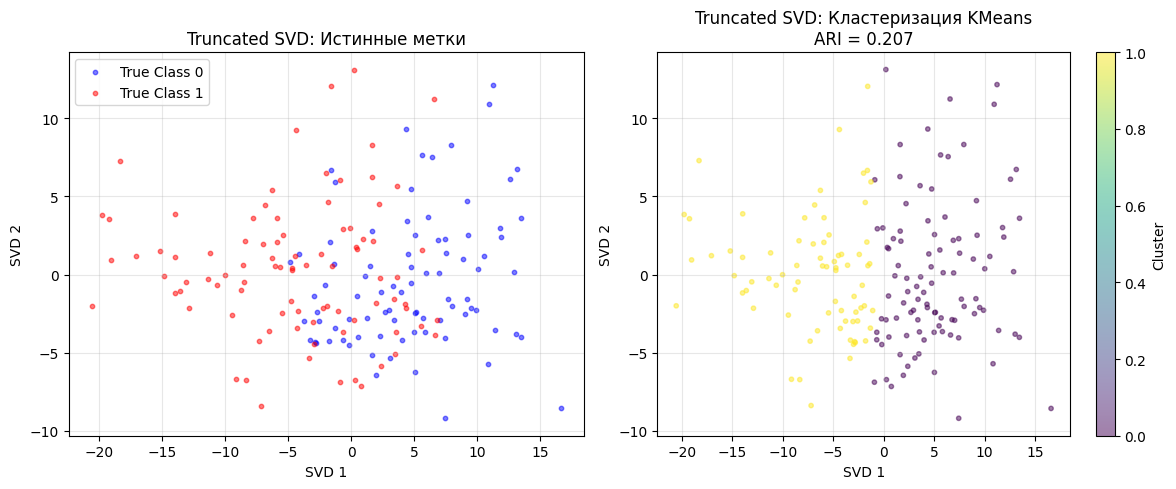

5. Сравнительный анализ


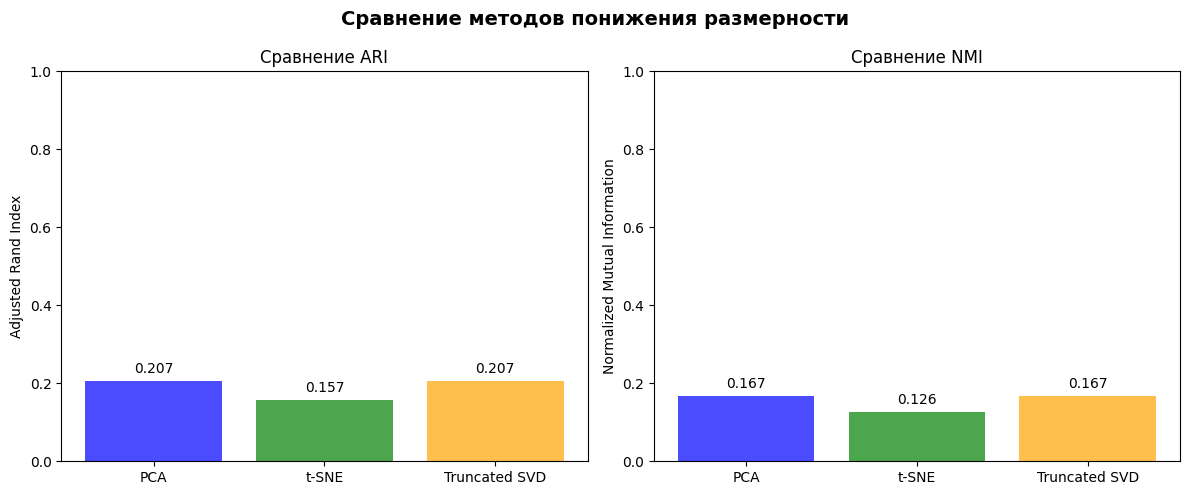


Итоговые рекомендации:
Лучший метод по ARI: PCA (ARI = 0.2069)
Лучший метод по NMI: PCA (NMI = 0.1674)


In [93]:
print("Подготовка данных...")
if new_df['class'].dtype == 'object':
    new_df = new_df.copy()
    new_df['class'] = new_df['class'].map({'P': 1, 'H': 0})
numeric_columns = new_df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Всего столбцов в датасете: {len(new_df.columns)}")
print(f"Числовых столбцов: {len(numeric_columns)}")
if 'class' not in numeric_columns:
    print("Ошибка: столбец 'class' не является числовым")
    le = LabelEncoder()
    new_df['class'] = le.fit_transform(new_df['class'])
    numeric_columns = new_df.select_dtypes(include=[np.number]).columns.tolist()
feature_columns = [col for col in numeric_columns if col != 'class']
X = new_df[feature_columns].values
y = new_df['class'].values
print(f"Размерность исходных данных: {X.shape}")
print(f"Количество признаков: {len(feature_columns)}")
print(f"Первые 5 признаков: {feature_columns[:5]}")
print(f"\nПроверка данных:")
print(f"NaN значений: {np.isnan(X).sum()}")
print(f"Бесконечных значений: {np.isinf(X).sum()}")
if np.isnan(X).sum() > 0:
    print("Заполняем NaN значения средними...")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='mean')
    X = imputer.fit_transform(X)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"\nДанные после стандартизации:")
print(f"Среднее: {X_scaled.mean():.6f}")
print(f"Стандартное отклонение: {X_scaled.std():.6f}")

print("1. PCA (Principal Component Analysis)")
n_components = min(50, X_scaled.shape[1])
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f"Размерность после PCA: {X_pca.shape}")
print(f"Объясненная дисперсия для {n_components} компонент: {pca.explained_variance_ratio_.sum():.2%}")
cumsum = np.cumsum(pca.explained_variance_ratio_)
n_components_95 = np.argmax(cumsum >= 0.95) + 1
print(f"Количество компонент для 95% дисперсии: {n_components_95}")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cumsum[:min(50, len(cumsum))], 'bo-', linewidth=2)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('PCA: Накопленная дисперсия')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.bar(range(1, min(11, len(pca.explained_variance_ratio_) + 1)),pca.explained_variance_ratio_[:10], alpha=0.7)
plt.xlabel('Главные компоненты')
plt.ylabel('Объясненная дисперсия')
plt.title('PCA: Первые 10 компонент')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
if X_pca.shape[1] >= 2:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], c='blue', label='Class 0 (Normal)', alpha=0.5, s=10)
    plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], c='red', label='Class 1 (Fraud)', alpha=0.5, s=10)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.title('PCA: Визуализация первых двух компонент')
    plt.legend()
    plt.grid(True, alpha=0.3)
    if X_pca.shape[1] >= 3:
        plt.subplot(1, 2, 2)
        plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 2], c='blue', label='Class 0 (Normal)', alpha=0.5, s=10)
        plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 2], c='red', label='Class 1 (Fraud)', alpha=0.5, s=10)
        plt.xlabel('PC1')
        plt.ylabel('PC3')
        plt.title('PCA: Визуализация PC1 и PC3')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("2. t-SNE (t-Distributed Stochastic Neighbor Embedding)")
sample_size = min(1000, len(X_scaled))
if len(X_scaled) > sample_size:
    np.random.seed(42)
    indices = np.random.choice(len(X_scaled), sample_size, replace=False)
    X_tsne_sample = X_scaled[indices]
    y_tsne_sample = y[indices]
else:
    X_tsne_sample = X_scaled
    y_tsne_sample = y
print(f"Используется {len(X_tsne_sample)} образцов для t-SNE")
tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, len(X_tsne_sample)-1), n_iter=1000)
X_tsne = tsne.fit_transform(X_tsne_sample)
print(f"Размерность после t-SNE: {X_tsne.shape}")
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X_tsne[y_tsne_sample == 0, 0], X_tsne[y_tsne_sample == 0, 1],
            c='blue', label='Class 0 (Normal)', alpha=0.5, s=10)
plt.scatter(X_tsne[y_tsne_sample == 1, 0], X_tsne[y_tsne_sample == 1, 1],
            c='red', label='Class 1 (Fraud)', alpha=0.5, s=10)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE: Визуализация')
plt.legend()
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.hist2d(X_tsne[:, 0], X_tsne[:, 1], bins=50, cmap='viridis')
plt.colorbar(label='Плотность')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE: Карта плотности')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("3. Truncated SVD (Singular Value Decomposition)")
n_svd_components = min(50, X_scaled.shape[1])
svd = TruncatedSVD(n_components=n_svd_components, random_state=42, n_iter=10)
X_svd = svd.fit_transform(X_scaled)
explained_variance_ratio_svd = svd.explained_variance_ratio_
cumsum_svd = np.cumsum(explained_variance_ratio_svd)
print(f"Размерность после Truncated SVD: {X_svd.shape}")
print(f"Объясненная дисперсия для {n_svd_components} компонент: {cumsum_svd[-1]:.2%}")
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(cumsum_svd[:20], 'bo-', linewidth=2)
plt.xlabel('Количество компонент')
plt.ylabel('Накопленная дисперсия')
plt.title('Truncated SVD: Накопленная дисперсия')
plt.grid(True, alpha=0.3)
plt.subplot(1, 2, 2)
plt.bar(range(1, min(11, len(explained_variance_ratio_svd) + 1)),
        explained_variance_ratio_svd[:10], alpha=0.7)
plt.xlabel('Компоненты')
plt.ylabel('Объясненная дисперсия')
plt.title('Truncated SVD: Первые 10 компонент')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
if X_svd.shape[1] >= 2:
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.scatter(X_svd[y == 0, 0], X_svd[y == 0, 1], c='blue', label='Class 0 (Normal)', alpha=0.5, s=10)
    plt.scatter(X_svd[y == 1, 0], X_svd[y == 1, 1], c='red', label='Class 1 (Fraud)', alpha=0.5, s=10)
    plt.xlabel('SVD 1')
    plt.ylabel('SVD 2')
    plt.title('Truncated SVD: Первые две компоненты')
    plt.legend()
    plt.grid(True, alpha=0.3)
    if X_svd.shape[1] >= 3:
        plt.subplot(1, 2, 2)
        plt.scatter(X_svd[y == 0, 0], X_svd[y == 0, 2], c='blue', label='Class 0 (Normal)', alpha=0.5, s=10)
        plt.scatter(X_svd[y == 1, 0], X_svd[y == 1, 2], c='red', label='Class 1 (Fraud)', alpha=0.5, s=10)
        plt.xlabel('SVD 1')
        plt.ylabel('SVD 3')
        plt.title('Truncated SVD: Компоненты 1 и 3')
        plt.legend()
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print("4. Кластеризация на пониженных размерностях")
def cluster_and_evaluate(X_reduced, y_true, method_name):
    try:
        kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
        y_pred = kmeans.fit_predict(X_reduced)
        silhouette = silhouette_score(X_reduced, y_pred)
        ari = adjusted_rand_score(y_true, y_pred)
        nmi = normalized_mutual_info_score(y_true, y_pred)
        print(f"\n{method_name}:")
        print(f"  Silhouette Score: {silhouette:.4f}")
        print(f"  Adjusted Rand Index: {ari:.4f}")
        print(f"  Normalized Mutual Information: {nmi:.4f}")
        return y_pred, kmeans
    except Exception as e:
        print(f"\n{method_name}: Ошибка - {e}")
        return None, None

if X_pca.shape[1] >= 2:
    y_pred_pca, kmeans_pca = cluster_and_evaluate(X_pca[:, :min(10, X_pca.shape[1])], y, "KMeans на PCA")
    if y_pred_pca is not None:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.scatter(X_pca[y == 0, 0], X_pca[y == 0, 1], c='blue', label='True Class 0', alpha=0.5, s=10)
        plt.scatter(X_pca[y == 1, 0], X_pca[y == 1, 1], c='red', label='True Class 1', alpha=0.5, s=10)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title('PCA: Истинные метки')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred_pca, cmap='viridis', alpha=0.5, s=10)
        plt.xlabel('PC1')
        plt.ylabel('PC2')
        plt.title(f'PCA: Кластеризация KMeans\nARI = {adjusted_rand_score(y, y_pred_pca):.3f}')
        plt.colorbar(label='Cluster')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if X_tsne.shape[0] == len(y_tsne_sample):
    y_pred_tsne, kmeans_tsne = cluster_and_evaluate(X_tsne, y_tsne_sample, "KMeans на t-SNE")
    if y_pred_tsne is not None:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.scatter(X_tsne[y_tsne_sample == 0, 0], X_tsne[y_tsne_sample == 0, 1],
                    c='blue', label='True Class 0', alpha=0.5, s=10)
        plt.scatter(X_tsne[y_tsne_sample == 1, 0], X_tsne[y_tsne_sample == 1, 1],
                    c='red', label='True Class 1', alpha=0.5, s=10)
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.title('t-SNE: Истинные метки')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_pred_tsne, cmap='viridis', alpha=0.5, s=10)
        plt.xlabel('t-SNE 1')
        plt.ylabel('t-SNE 2')
        plt.title(f't-SNE: Кластеризация KMeans\nARI = {adjusted_rand_score(y_tsne_sample, y_pred_tsne):.3f}')
        plt.colorbar(label='Cluster')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

if X_svd.shape[1] >= 2:
    y_pred_svd, kmeans_svd = cluster_and_evaluate(X_svd[:, :min(10, X_svd.shape[1])], y, "KMeans на Truncated SVD")
    if y_pred_svd is not None:
        plt.figure(figsize=(12, 5))
        plt.subplot(1, 2, 1)
        plt.scatter(X_svd[y == 0, 0], X_svd[y == 0, 1], c='blue', label='True Class 0', alpha=0.5, s=10)
        plt.scatter(X_svd[y == 1, 0], X_svd[y == 1, 1], c='red', label='True Class 1', alpha=0.5, s=10)
        plt.xlabel('SVD 1')
        plt.ylabel('SVD 2')
        plt.title('Truncated SVD: Истинные метки')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.subplot(1, 2, 2)
        plt.scatter(X_svd[:, 0], X_svd[:, 1], c=y_pred_svd, cmap='viridis', alpha=0.5, s=10)
        plt.xlabel('SVD 1')
        plt.ylabel('SVD 2')
        plt.title(f'Truncated SVD: Кластеризация KMeans\nARI = {adjusted_rand_score(y, y_pred_svd):.3f}')
        plt.colorbar(label='Cluster')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

print("5. Сравнительный анализ")
methods = ['PCA', 't-SNE', 'Truncated SVD']
ari_scores = []
nmi_scores = []

if 'y_pred_pca' in locals() and y_pred_pca is not None:
    ari_scores.append(adjusted_rand_score(y, y_pred_pca))
    nmi_scores.append(normalized_mutual_info_score(y, y_pred_pca))
else:
    ari_scores.append(0)
    nmi_scores.append(0)

if 'y_pred_tsne' in locals() and y_pred_tsne is not None:
    ari_scores.append(adjusted_rand_score(y_tsne_sample, y_pred_tsne))
    nmi_scores.append(normalized_mutual_info_score(y_tsne_sample, y_pred_tsne))
else:
    ari_scores.append(0)
    nmi_scores.append(0)

if 'y_pred_svd' in locals() and y_pred_svd is not None:
    ari_scores.append(adjusted_rand_score(y, y_pred_svd))
    nmi_scores.append(normalized_mutual_info_score(y, y_pred_svd))
else:
    ari_scores.append(0)
    nmi_scores.append(0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.bar(methods, ari_scores, color=['blue', 'green', 'orange'], alpha=0.7)
ax1.set_ylabel('Adjusted Rand Index')
ax1.set_title('Сравнение ARI')
ax1.set_ylim(0, 1)
for i, v in enumerate(ari_scores):
    ax1.text(i, v + 0.02, f'{v:.3f}', ha='center')
ax2.bar(methods, nmi_scores, color=['blue', 'green', 'orange'], alpha=0.7)
ax2.set_ylabel('Normalized Mutual Information')
ax2.set_title('Сравнение NMI')
ax2.set_ylim(0, 1)
for i, v in enumerate(nmi_scores):
    ax2.text(i, v + 0.02, f'{v:.3f}', ha='center')
plt.suptitle('Сравнение методов понижения размерности', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nИтоговые рекомендации:")
if max(ari_scores) > 0:
    best_method = methods[np.argmax(ari_scores)]
    print(f"Лучший метод по ARI: {best_method} (ARI = {max(ari_scores):.4f})")
    print(f"Лучший метод по NMI: {methods[np.argmax(nmi_scores)]} (NMI = {max(nmi_scores):.4f})")
else:
    print("Не удалось получить значимые результаты кластеризации")